**ROLL NO : 24BAD087**  
**NAME : POOVIKA M**

**EXP NO : 5**

**IMPLEMENTATION OF A RECURRENT NEURAL NETWORK (RNN) FOR TEXT GENERATION**

PART A — DATASET PREPARATION

In [1]:
#Import libraries

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import re

from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("Libraries imported successfully.")
print("TensorFlow Version:", tf.__version__)

Libraries imported successfully.
TensorFlow Version: 2.20.0


In [2]:
# Load Tiny Shakespeare dataset from Hugging Face

dataset = load_dataset("Trelis/tiny-shakespeare")

print("Dataset:")
print(dataset)

print("\nTraining samples:", len(dataset["train"]))
print("Testing samples:", len(dataset["test"]))

print("\nColumn names:")
print(dataset["train"].column_names)

print("\nSample text:")
print(dataset["train"][0]["Text"][:1000])

README.md:   0%|          | 0.00/497 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.22M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/119k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/472 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/49 [00:00<?, ? examples/s]

Dataset:
DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

Training samples: 472
Testing samples: 49

Column names:
['Text']

Sample text:
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
a

In [3]:
# Extract all training text

train_texts = dataset["train"]["Text"]

# Combine all text records
text = "\n".join(train_texts)

# Convert to lowercase
text = text.lower()

print("Total characters:", len(text))

print("\nSample after preprocessing:")
print(text[:500])

Total characters: 1222825

Sample after preprocessing:
first citizen:
before we proceed any further, hear me speak.

all:
speak, speak.

first citizen:
you are all resolved rather to die than to famish?

all:
resolved. resolved.

first citizen:
first, you know caius marcius is chief enemy to the people.

all:
we know't, we know't.

first citizen:
let us kill him, and we'll have corn at our own price.
is't a verdict?

all:
no more talking on't; let it be done: away, away!

second citizen:
one word, good citizens.

first citizen:
we are accounted poor


In [4]:
# Tokenize text into individual words

words = re.findall(r"\b[a-zA-Z']+\b", text)

print("Total number of words:", len(words))

print("\nFirst 30 words:")
print(words[:30])

Total number of words: 223610

First 30 words:
['first', 'citizen', 'before', 'we', 'proceed', 'any', 'further', 'hear', 'me', 'speak', 'all', 'speak', 'speak', 'first', 'citizen', 'you', 'are', 'all', 'resolved', 'rather', 'to', 'die', 'than', 'to', 'famish', 'all', 'resolved', 'resolved', 'first', 'citizen']


In [5]:
# Build vocabulary and assign integer index to each word

tokenizer = Tokenizer(
    num_words=10000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts([text])

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))

print("\nFirst 20 vocabulary entries:")

for word, index in list(word_index.items())[:20]:
    print(word, ":", index)

Vocabulary size: 11980

First 20 vocabulary entries:
<OOV> : 1
the : 2
and : 3
to : 4
i : 5
of : 6
my : 7
you : 8
a : 9
that : 10
in : 11
is : 12
not : 13
for : 14
with : 15
me : 16
it : 17
your : 18
be : 19
his : 20


In [6]:
# Convert text into integer sequence

token_sequence = tokenizer.texts_to_sequences([text])[0]

print("Number of tokens:", len(token_sequence))

print("\nFirst 30 token indices:")
print(token_sequence[:30])

Number of tokens: 223886

First 30 token indices:
[80, 261, 150, 35, 876, 149, 651, 128, 16, 107, 36, 107, 107, 80, 261, 8, 42, 36, 1383, 348, 4, 193, 66, 4, 4237, 36, 1383, 1383, 80, 261]


In [7]:
# Generate sequences for next-word prediction

sequence_length = 10

sequences = []

for i in range(sequence_length, len(token_sequence)):
    sequence = token_sequence[i-sequence_length:i+1]
    sequences.append(sequence)

sequences = np.array(sequences)

print("Number of sequences:", len(sequences))
print("Sequence shape:", sequences.shape)

print("\nExample sequence:")
print(sequences[0])

Number of sequences: 223876
Sequence shape: (223876, 11)

Example sequence:
[ 80 261 150  35 876 149 651 128  16 107  36]


In [8]:
# Separate input sequence and target word

X = sequences[:, :-1]
y = sequences[:, -1]

print("Input shape:", X.shape)
print("Target shape:", y.shape)

print("\nInput sequence:")
print(X[0])

print("\nTarget:")
print(y[0])

Input shape: (223876, 10)
Target shape: (223876,)

Input sequence:
[ 80 261 150  35 876 149 651 128  16 107]

Target:
36


In [9]:
# Apply sequence padding

X = pad_sequences(
    X,
    maxlen=sequence_length,
    padding="pre"
)

print("Padding completed.")

print("Padded input shape:", X.shape)

print("\nExample padded sequence:")
print(X[0])

Padding completed.
Padded input shape: (223876, 10)

Example padded sequence:
[ 80 261 150  35 876 149 651 128  16 107]


In [10]:
# Split data into training and validation sets

split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining input shape:", X_train.shape)
print("Training target shape:", y_train.shape)

print("\nValidation input shape:", X_val.shape)
print("Validation target shape:", y_val.shape)

Training samples: 179100
Validation samples: 44776

Training input shape: (179100, 10)
Training target shape: (179100,)

Validation input shape: (44776, 10)
Validation target shape: (44776,)


In [11]:
print("=" * 50)
print("PART A - DATASET PREPARATION")
print("=" * 50)

print("Dataset: Tiny Shakespeare")
print("Vocabulary size:", len(word_index))
print("Sequence length:", sequence_length)
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nDataset preparation completed successfully.")

PART A - DATASET PREPARATION
Dataset: Tiny Shakespeare
Vocabulary size: 11980
Sequence length: 10
Training samples: 179100
Validation samples: 44776

Dataset preparation completed successfully.


PART B — IMPLEMENTING THE RNN MODEL

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense

# Vocabulary size
vocab_size = min(10000, len(word_index) + 1)

# Create RNN model
model = Sequential([
    Input(shape=(sequence_length,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    SimpleRNN(
        128
    ),

    Dense(
        vocab_size,
        activation="softmax"
    )
])

print("RNN model created successfully.")

RNN model created successfully.


In [13]:
# Compile the model

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")
print("Optimizer: Adam")
print("Loss: Sparse Categorical Crossentropy")

Model compiled successfully.
Optimizer: Adam
Loss: Sparse Categorical Crossentropy


In [14]:
# Display model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 10, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10000)          │     1,290,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,602,896 (9.93 MB)

 Trainable params: 2,602,896 (9.93 MB)

 Non-trainable params: 0 (0.00 B)

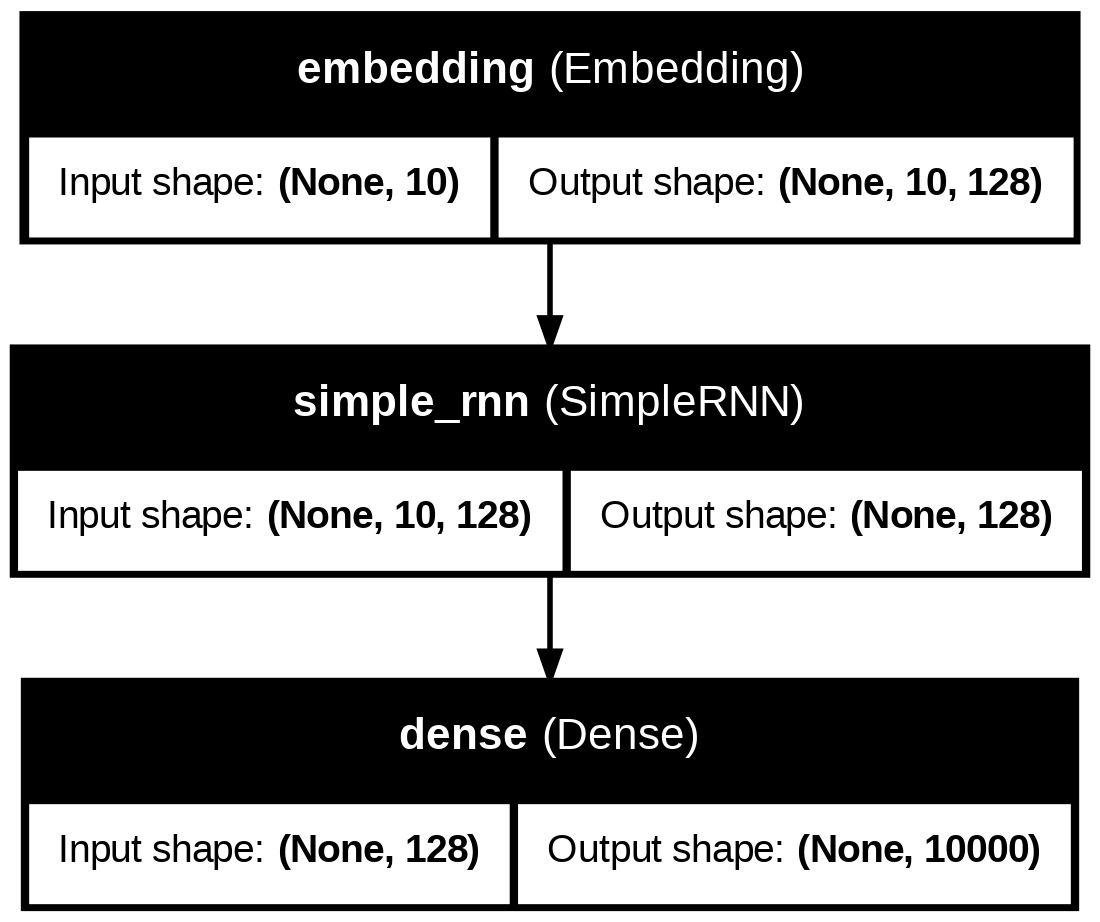

In [15]:
# Display model architecture diagram

tf.keras.utils.plot_model(
    model,
    show_shapes=True,
    show_layer_names=True
)

PART C — TRAINING AND EVALUATION

In [17]:
# Train the RNN model

epochs = 10
batch_size = 128

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    verbose=1
)

Epoch 1/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 124s 89ms/step - accuracy: 0.1083 - loss: 5.5226 - val_accuracy: 0.0834 - val_loss: 6.5999
Epoch 2/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 145s 91ms/step - accuracy: 0.1268 - loss: 5.1895 - val_accuracy: 0.0820 - val_loss: 6.7091
Epoch 3/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 136s 97ms/step - accuracy: 0.1489 - loss: 4.8825 - val_accuracy: 0.0786 - val_loss: 6.8309
Epoch 4/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 137s 94ms/step - accuracy: 0.1771 - loss: 4.5920 - val_accuracy: 0.0774 - val_loss: 6.9789
Epoch 5/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 124s 88ms/step - accuracy: 0.2091 - loss: 4.3198 - val_accuracy: 0.0736 - val_loss: 7.1358
Epoch 6/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 142s 89ms/step - accuracy: 0.2418 - loss: 4.0660 - val_accuracy: 0.0707 - val_loss: 7.2850
Epoch 7/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 126s 90ms/step - accuracy: 0.2758 - loss: 3.8312 - val_accuracy: 0.0667 - val_loss: 7.4426
Epoch 8/10
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 132s 95ms/step - accuracy: 

In [18]:
# Record final training and validation results

train_accuracy = history.history["accuracy"][-1]
val_accuracy = history.history["val_accuracy"][-1]

train_loss = history.history["loss"][-1]
val_loss = history.history["val_loss"][-1]

print("=" * 50)
print("TRAINING RESULTS")
print("=" * 50)

print(f"Training Accuracy   : {train_accuracy:.4f}")
print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Training Loss       : {train_loss:.4f}")
print(f"Validation Loss     : {val_loss:.4f}")

TRAINING RESULTS
Training Accuracy   : 0.3683
Validation Accuracy : 0.0590
Training Loss       : 3.2406
Validation Loss     : 7.8849


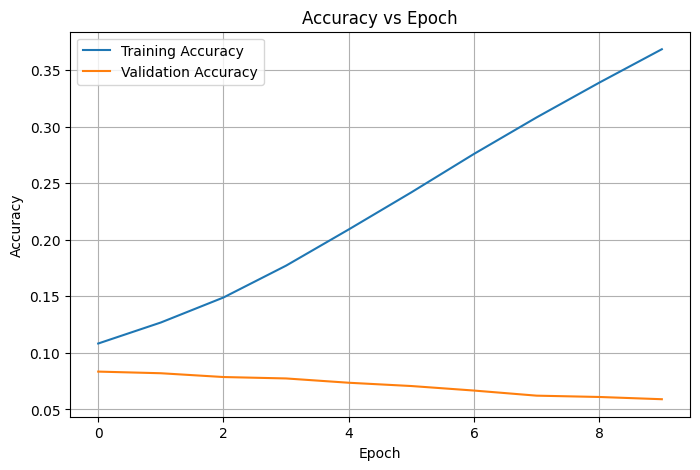

In [19]:
# Accuracy vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

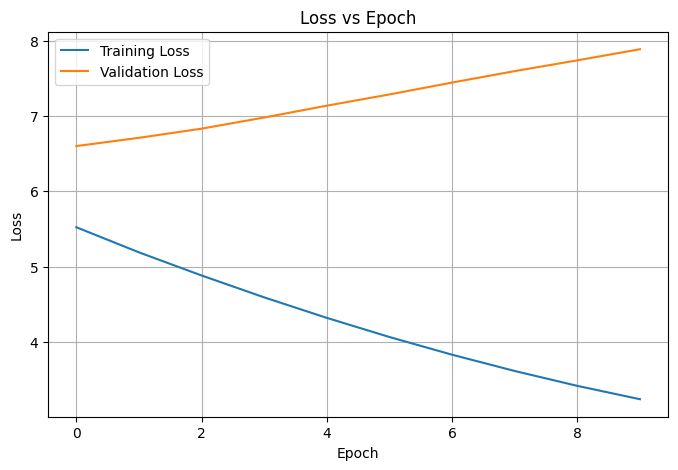

In [20]:
# Loss vs Epoch

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Display training results for every epoch

print("Epoch-wise Results")
print("-" * 70)

for i in range(epochs):
    print(
        f"Epoch {i+1:02d} | "
        f"Train Acc: {history.history['accuracy'][i]:.4f} | "
        f"Val Acc: {history.history['val_accuracy'][i]:.4f} | "
        f"Train Loss: {history.history['loss'][i]:.4f} | "
        f"Val Loss: {history.history['val_loss'][i]:.4f}"
    )

Epoch-wise Results
----------------------------------------------------------------------
Epoch 01 | Train Acc: 0.1083 | Val Acc: 0.0834 | Train Loss: 5.5226 | Val Loss: 6.5999
Epoch 02 | Train Acc: 0.1268 | Val Acc: 0.0820 | Train Loss: 5.1895 | Val Loss: 6.7091
Epoch 03 | Train Acc: 0.1489 | Val Acc: 0.0786 | Train Loss: 4.8825 | Val Loss: 6.8309
Epoch 04 | Train Acc: 0.1771 | Val Acc: 0.0774 | Train Loss: 4.5920 | Val Loss: 6.9789
Epoch 05 | Train Acc: 0.2091 | Val Acc: 0.0736 | Train Loss: 4.3198 | Val Loss: 7.1358
Epoch 06 | Train Acc: 0.2418 | Val Acc: 0.0707 | Train Loss: 4.0660 | Val Loss: 7.2850
Epoch 07 | Train Acc: 0.2758 | Val Acc: 0.0667 | Train Loss: 3.8312 | Val Loss: 7.4426
Epoch 08 | Train Acc: 0.3081 | Val Acc: 0.0622 | Train Loss: 3.6152 | Val Loss: 7.5945
Epoch 09 | Train Acc: 0.3388 | Val Acc: 0.0610 | Train Loss: 3.4178 | Val Loss: 7.7374
Epoch 10 | Train Acc: 0.3683 | Val Acc: 0.0590 | Train Loss: 3.2406 | Val Loss: 7.8849


PART D — TEXT GENERATION

In [22]:
# Create reverse vocabulary

index_to_word = {
    index: word
    for word, index in word_index.items()
}

print("Vocabulary mapping created successfully.")

Vocabulary mapping created successfully.


In [23]:
# Function for next-word prediction and text generation

def generate_text(seed_text, next_words=30):

    generated_text = seed_text.lower()

    for _ in range(next_words):

        # Convert seed text into integers
        token_list = tokenizer.texts_to_sequences(
            [generated_text]
        )[0]

        # Keep only the last sequence_length words
        token_list = token_list[-sequence_length:]

        # Apply padding
        token_list = pad_sequences(
            [token_list],
            maxlen=sequence_length,
            padding="pre"
        )

        # Predict next word
        prediction = model.predict(
            token_list,
            verbose=0
        )

        predicted_index = np.argmax(prediction[0])

        # Convert index back to word
        predicted_word = index_to_word.get(
            predicted_index,
            ""
        )

        if predicted_word == "":
            break

        # Add predicted word
        generated_text += " " + predicted_word

    return generated_text

In [24]:
# Sample 1

seed1 = "to be or not to be"

generated1 = generate_text(
    seed1,
    next_words=30
)

print("Seed:")
print(seed1)

print("\nGenerated Text:")
print(generated1)

Seed:
to be or not to be

Generated Text:
to be or not to be but now the sky is it ' by sovereignty which as a traitor in this action finding him in my life and that we have been many years of death


In [25]:
# Sample 2

seed2 = "the king"

generated2 = generate_text(
    seed2,
    next_words=30
)

print("Seed:")
print(seed2)

print("\nGenerated Text:")
print(generated2)

Seed:
the king

Generated Text:
the king that have the steerage of the moonshine's watery beams of waters and himself the times of rome is it with all that turns him to our country are into a


In [26]:
# Sample 3

seed3 = "my lord"

generated3 = generate_text(
    seed3,
    next_words=30
)

print("Seed:")
print(seed3)

print("\nGenerated Text:")
print(generated3)

Seed:
my lord

Generated Text:
my lord leontes had he been too much of thy name i have a villain romeo i will i see him even so i am in a man that care not say


In [27]:
# Generate multiple text samples using different seed inputs

seeds = [
    "to be or not to be",
    "the king",
    "my lord",
    "what is this"
]

for seed in seeds:

    result = generate_text(
        seed,
        next_words=25
    )

    print("\n" + "=" * 60)
    print("Seed:", seed)
    print("Generated Text:")
    print(result)


Seed: to be or not to be
Generated Text:
to be or not to be but now the sky is it ' by sovereignty which as a traitor in this action finding him in my life and that we have

Seed: the king
Generated Text:
the king that have the steerage of the moonshine's watery beams of waters and himself the times of rome is it with all that turns him to

Seed: my lord
Generated Text:
my lord leontes had he been too much of thy name i have a villain romeo i will i see him even so i am in a

Seed: what is this
Generated Text:
what is this news juliet is not so hot juliet is not my good lord leontes i have done a father of the feast but it so he


### Observations

1. The RNN learned sequential patterns from the Tiny Shakespeare dataset.

2. The Embedding layer converted integer word indices into dense vector representations.

3. The Simple RNN learned relationships between words in the sequence.

4. The Dense layer with Softmax predicted the probability of the next word.

5. Different seed inputs produced different generated text.

6. The generated text showed patterns similar to the original Shakespeare-style text.

7. The coherence of generated text depends on training, sequence length, and the amount of available data.

8. A Simple RNN may have difficulty learning long-term dependencies in longer sequences.